# Adaptive Chirp Mode Decomposition (ACMD)

**ACMD** (Chen *et al.*, 2018) extracts amplitude- and frequency-modulated chirp modes by
iteratively demodulating a signal against a kernel built from an instantaneous-frequency (IF)
guess, then refining that IF via arctangent demodulation and Tikhonov smoothing.

This notebook reproduces the MATLAB demos:

- **Test1** — Fourier-peak IF initialization (two fast-oscillating IFs)
- **Test2** — STFT ridge IF initialization (three polynomial chirps + noise)

**References**

> S. Chen, Y. Yang, Z. Peng, *et al.*  
> *Detection of Rub-Impact Fault for Rotor-Stator Systems: A Novel Method Based on Adaptive Chirp Mode Decomposition.*  
> Journal of Sound and Vibration, 2018.

MATLAB code: [File Exchange 69128](https://www.mathworks.com/matlabcentral/fileexchange/69128-adaptive-chirp-mode-decomposition).

## 1. Imports

In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import ACMD
from pysdkit._acmd.acmd import (
    add_noise,
    compute_snr,
    curve_smooth,
    find_ridges,
    stft,
    tf_spectrum,
)

print(ACMD(K=2, fs=1000))

Adaptive Chirp Mode Decomposition (ACMD)


## 2. Test1 — Fourier-peak IF initialization

Two exponentially decaying chirps with fast sinusoidal IF modulation (`SampFreq = 1000` Hz).
Initial IF for each residual is taken as the peak of its Fourier spectrum (constant IF seed).

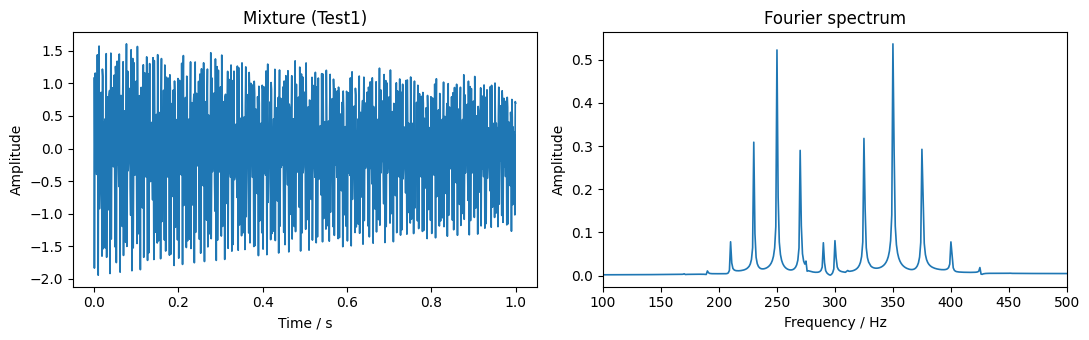

In [4]:
fs1 = 1000.0
t1 = np.arange(0.0, 1.0 + 1.0 / fs1, 1.0 / fs1)

sig1 = np.exp(-0.3 * t1) * np.cos(
    2 * np.pi * (350 * t1 + (1.0 / (2 * np.pi)) * np.cos(2 * np.pi * 25 * t1))
)
if1_true = 350 - 25 * np.sin(50 * np.pi * t1)

sig2 = np.exp(-0.6 * t1) * np.cos(
    2 * np.pi * (250 * t1 + (1.0 / (2 * np.pi)) * np.cos(2 * np.pi * 20 * t1))
)
if2_true = 250 - 20 * np.sin(40 * np.pi * t1)

sig = sig1 + sig2

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(t1, sig, lw=1.2)
axes[0].set_xlabel("Time / s")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Mixture (Test1)")

spec = 2 * np.abs(np.fft.fft(sig)) / len(sig)
half = int(len(sig) / 2.0 + 0.5)
spec = spec[:half]
freq = np.linspace(0, fs1 / 2, len(spec))
axes[1].plot(freq, spec, lw=1.2)
axes[1].set_xlim(100, 500)
axes[1].set_xlabel("Frequency / Hz")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Fourier spectrum")
fig.tight_layout()
plt.show()

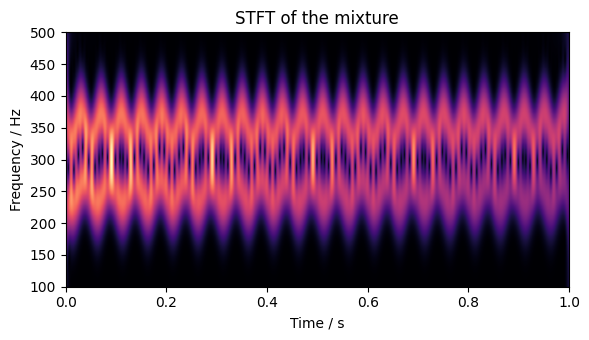

In [5]:
tf_spec1, f_stft1 = stft(sig, fs1, n_fft=512, win_len=32)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.imshow(
    np.abs(tf_spec1),
    extent=[t1[0], t1[-1], f_stft1[0], f_stft1[-1]],
    aspect="auto",
    origin="lower",
    cmap="magma",
)
ax.set_ylim(100, 500)
ax.set_xlabel("Time / s")
ax.set_ylabel("Frequency / Hz")
ax.set_title("STFT of the mixture")
fig.tight_layout()
plt.show()

In [6]:
alpha0, beta, tol = 1e-3, 1e-4, 1e-8
acmd1 = ACMD(K=2, fs=fs1, alpha0=alpha0, beta=beta, tol=tol, max_iter=300)
imfs1, ifs1, ias1 = acmd1.fit_transform(sig, return_all=True)

print(f"SNR mode1 vs Sig1: {compute_snr(sig1, imfs1[0]):.2f} dB")
print(f"SNR mode2 vs Sig2: {compute_snr(sig2, imfs1[1]):.2f} dB")
# reorder if peak order swapped
if compute_snr(sig1, imfs1[0]) < compute_snr(sig1, imfs1[1]):
    imfs1 = imfs1[::-1]
    ifs1 = ifs1[::-1]
    ias1 = ias1[::-1]
    print("(modes reordered to match Sig1, Sig2)")
    print(f"SNR mode1 vs Sig1: {compute_snr(sig1, imfs1[0]):.2f} dB")
    print(f"SNR mode2 vs Sig2: {compute_snr(sig2, imfs1[1]):.2f} dB")

SNR mode1 vs Sig1: 23.97 dB
SNR mode2 vs Sig2: 29.16 dB


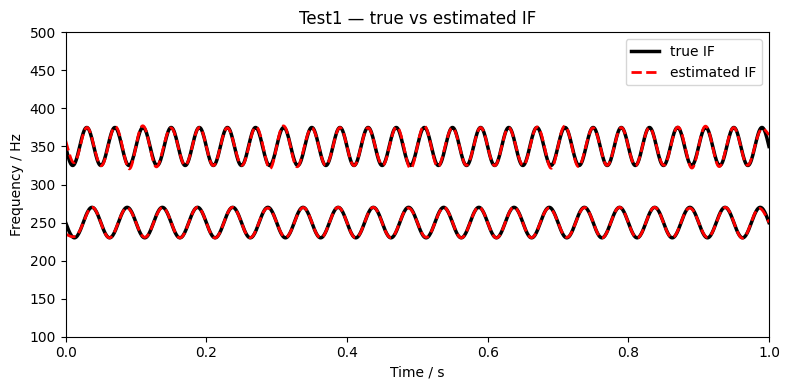

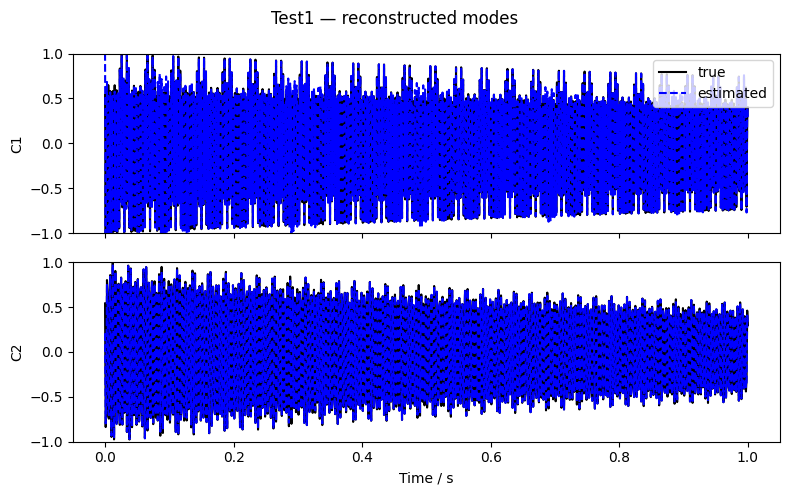

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t1, if1_true, "k", lw=2.5, label="true IF")
ax.plot(t1, if2_true, "k", lw=2.5)
ax.plot(t1, ifs1[0], "r--", lw=2, label="estimated IF")
ax.plot(t1, ifs1[1], "r--", lw=2)
ax.set_xlim(0, 1)
ax.set_ylim(100, 500)
ax.set_xlabel("Time / s")
ax.set_ylabel("Frequency / Hz")
ax.set_title("Test1 — true vs estimated IF")
ax.legend()
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(t1, sig1, "k", lw=1.5, label="true")
axes[0].plot(t1, imfs1[0], "b--", lw=1.5, label="estimated")
axes[0].set_ylabel("C1")
axes[0].set_ylim(-1, 1)
axes[0].legend(loc="upper right")
axes[1].plot(t1, sig2, "k", lw=1.5)
axes[1].plot(t1, imfs1[1], "b--", lw=1.5)
axes[1].set_ylabel("C2")
axes[1].set_xlabel("Time / s")
axes[1].set_ylim(-1, 1)
fig.suptitle("Test1 — reconstructed modes")
fig.tight_layout()
plt.show()

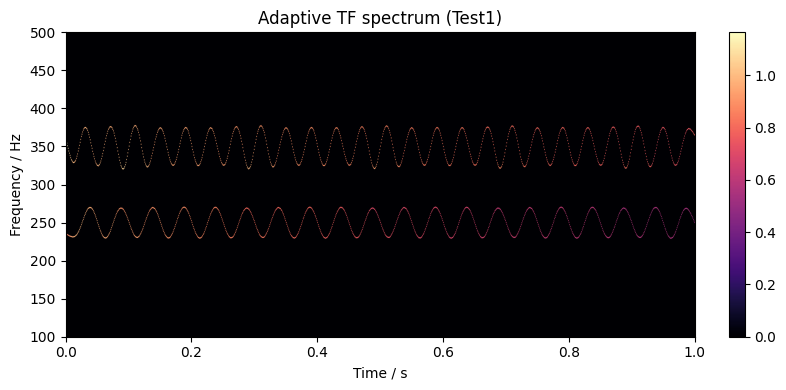

In [8]:
a_spec1, fbin1 = tf_spectrum(ifs1, ias1, band=(0.0, fs1 / 2.0))

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(
    np.abs(a_spec1),
    extent=[t1[0], t1[-1], fbin1[0], fbin1[-1]],
    aspect="auto",
    origin="lower",
    cmap="magma",
)
ax.set_ylim(100, 500)
ax.set_xlabel("Time / s")
ax.set_ylabel("Frequency / Hz")
ax.set_title("Adaptive TF spectrum (Test1)")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

## 3. Test2 — STFT-ridge IF initialization

Three polynomial chirps with additive Gaussian noise (`SampFreq = 500` Hz, `STD = 0.5`).
Each mode is seeded from a smoothed STFT ridge of the current residual, then refined by ACMD.

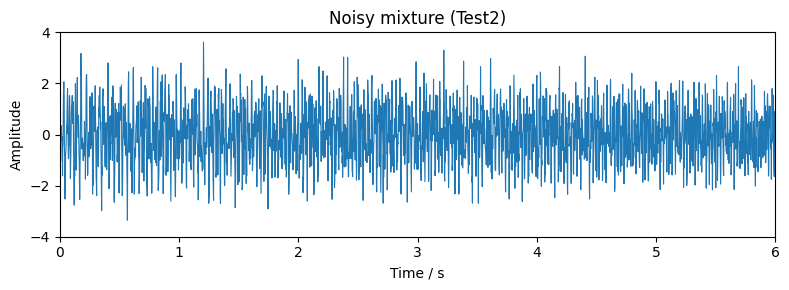

In [9]:
fs2 = 500.0
t2 = np.arange(0.0, 6.0 + 1.0 / fs2, 1.0 / fs2)

c1 = np.exp(-0.03 * t2) * np.cos(
    2 * np.pi * (1.3 + 25 * t2 + 4 * t2**2 - 0.8 * t2**3 + 0.07 * t2**4)
)
if1 = 25 + 8 * t2 - 2.4 * t2**2 + 0.28 * t2**3

c2 = 0.9 * np.exp(-0.06 * t2) * np.cos(
    2 * np.pi * (2.6 + 40 * t2 + 8 * t2**2 - 1.6 * t2**3 + 0.14 * t2**4)
)
if2 = 40 + 16 * t2 - 4.8 * t2**2 + 0.56 * t2**3

c3 = 0.8 * np.exp(-0.09 * t2) * np.cos(
    2 * np.pi * (3.9 + 60 * t2 + 12 * t2**2 - 2.4 * t2**3 + 0.21 * t2**4)
)
if3 = 60 + 24 * t2 - 7.2 * t2**2 + 0.84 * t2**3

clean = c1 + c2 + c3
rng = np.random.default_rng(0)
sign = clean + add_noise(len(clean), mean=0.0, std=0.5, rng=rng)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t2, sign, lw=0.8)
ax.set_xlim(0, 6)
ax.set_ylim(-4, 4)
ax.set_xlabel("Time / s")
ax.set_ylabel("Amplitude")
ax.set_title("Noisy mixture (Test2)")
fig.tight_layout()
plt.show()

In [10]:
alpha0_2, beta_2, delta_ridge, tol_2 = 1e-6, 1e-9, 20, 1e-8
acmd2 = ACMD(K=1, fs=fs2, alpha0=alpha0_2, beta=beta_2, tol=tol_2, max_iter=300)

residual = sign.copy()
sests, if_ests, ia_ests, ini_ifs = [], [], [], []

for k in range(3):
    tf_spec, f_axis = stft(residual, fs2, n_fft=1024, win_len=256)
    # keep non-negative frequencies for ridge search (matches visual band [0, 150])
    pos = f_axis >= 0
    tf_pos = tf_spec[pos]
    f_pos = f_axis[pos]
    idx = find_ridges(tf_pos, delta=delta_ridge)
    ini_if = curve_smooth(f_pos[idx], beta_2)
    sest, if_est, ia_est = acmd2.extract_mode(residual, ini_if)
    sests.append(sest)
    if_ests.append(if_est)
    ia_ests.append(ia_est)
    ini_ifs.append(ini_if)
    residual = residual - sest

sests = np.vstack(sests)
if_ests = np.vstack(if_ests)
ia_ests = np.vstack(ia_ests)
ini_ifs = np.vstack(ini_ifs)

trues = [c1, c2, c3]
true_ifs = [if1, if2, if3]
for i, (true, true_if) in enumerate(zip(trues, true_ifs)):
    print(
        f"Mode {i+1}: SNR={compute_snr(true, sests[i]):.2f} dB | "
        f"ini RE={np.linalg.norm(ini_ifs[i]-true_if)/np.linalg.norm(true_if):.4f} | "
        f"est RE={np.linalg.norm(if_ests[i]-true_if)/np.linalg.norm(true_if):.4f}"
    )

Mode 1: SNR=20.01 dB | ini RE=0.0100 | est RE=0.0015
Mode 2: SNR=18.81 dB | ini RE=0.0083 | est RE=0.0012
Mode 3: SNR=16.33 dB | ini RE=0.0074 | est RE=0.0010


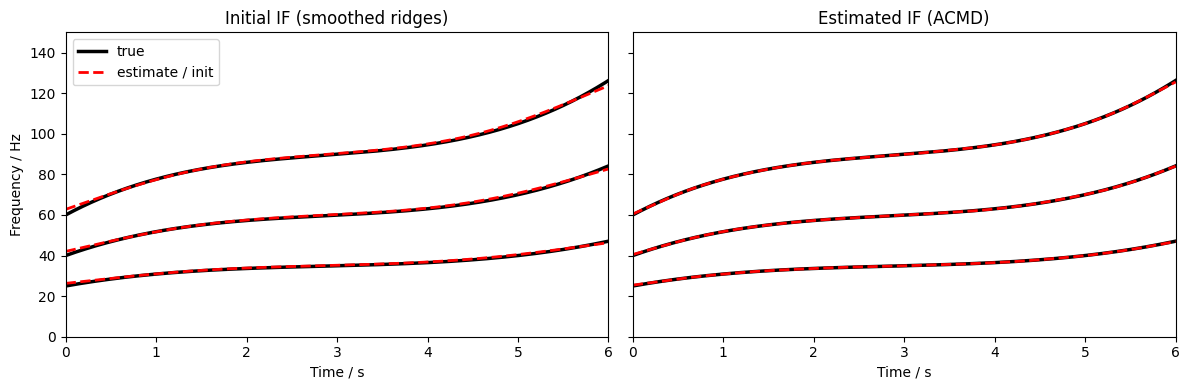

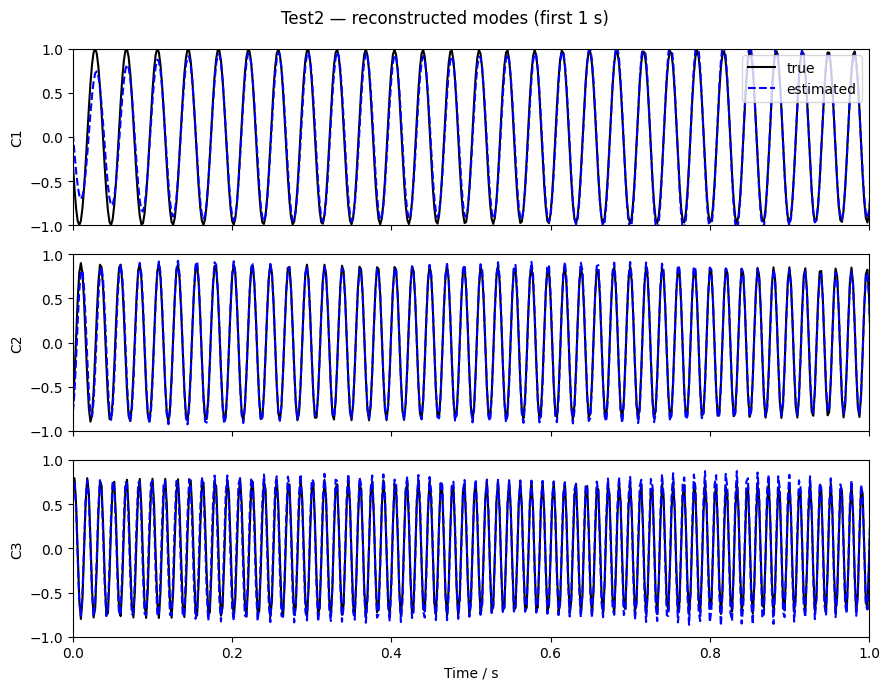

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, curves, title in zip(
    axes,
    [ini_ifs, if_ests],
    ["Initial IF (smoothed ridges)", "Estimated IF (ACMD)"],
):
    ax.plot(t2, if1, "k", lw=2.5, label="true")
    ax.plot(t2, if2, "k", lw=2.5)
    ax.plot(t2, if3, "k", lw=2.5)
    ax.plot(t2, curves[0], "r--", lw=2, label="estimate / init")
    ax.plot(t2, curves[1], "r--", lw=2)
    ax.plot(t2, curves[2], "r--", lw=2)
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 150)
    ax.set_xlabel("Time / s")
    ax.set_title(title)
axes[0].set_ylabel("Frequency / Hz")
axes[0].legend(loc="upper left")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, true, est, label in zip(axes, trues, sests, ["C1", "C2", "C3"]):
    ax.plot(t2, true, "k", lw=1.5, label="true")
    ax.plot(t2, est, "b--", lw=1.5, label="estimated")
    ax.set_ylabel(label)
    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 1)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time / s")
fig.suptitle("Test2 — reconstructed modes (first 1 s)")
fig.tight_layout()
plt.show()

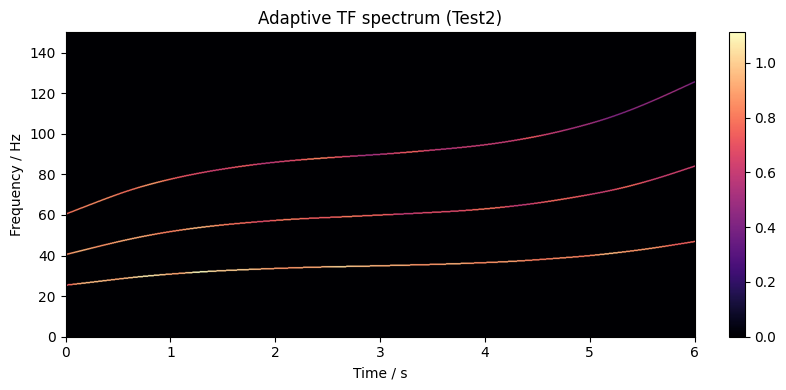

In [12]:
a_spec2, fbin2 = tf_spectrum(if_ests, ia_ests, band=(0.0, fs2 / 2.0))

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(
    np.abs(a_spec2),
    extent=[t2[0], t2[-1], fbin2[0], fbin2[-1]],
    aspect="auto",
    origin="lower",
    cmap="magma",
)
ax.set_ylim(0, 150)
ax.set_xlabel("Time / s")
ax.set_ylabel("Frequency / Hz")
ax.set_title("Adaptive TF spectrum (Test2)")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

## 4. Notes

- Recursive extraction continues until residual energy is small (here fixed `K` / three ridge passes).
- Larger `alpha0` tolerates rougher IF seeds but admits more noise / inter-mode leakage.
- Smaller `beta` smooths IF updates more aggressively (may miss very fast IF swings).
- Test2 ridge IF is limited by STFT resolution; ACMD typically reduces relative IF error vs. the ridge seed.